## Purpose
This notebook investigates what factors are associated with the size of forest fires recorded in the Montesinho Natural Park dataset, using burned area as the target variable. Every column in this dataset represents a fire with small fires having areas near zero (below 0.01 ha). Burned Area was chosen over alternatives like collasping area into a binary fire or no fire occurrence flag. This is because it captures fire *severity* rather than just presence, and because area is the outcome variable used in the original study this dataset comes from (Cortez & Morais, 2007) and in most subsequent work with it. Keeping the target consistent with prior research makes results here easier to compare against that existing body of work. Area is log transformed for modeling (justified via the histogram comparison in the
EDA section below) due to its extreme right skew, with most fire days recording near zero burned area and a small number of large outlier fires.

## Table of Contents

1. Data Load & Setup
2. Derive BUI and FWI from ISI, DMC, DC
3. Target Transform
4. Encode Categorical Features
5. Exploratory Data Analysis (area distribution, histograms, weather vs. FWI, correlation heatmap)
6. Unsupervised Clustering (KMeans on weather/fuel features)
7. Model Comparison (Linear Regression vs. RandomForest, Models A–G)
8. Final Diagnostics (best model selection, predicted vs. actual)

In [28]:
import os
# allows us to interact with the operating system (creating folders, building file paths, etc.) which we use below to make sure our output directory exists
import numpy as np
# allows us to use numpy, which gives us fast array/numeric operations that pandas and sklearn build on top of
import pandas as pd
# allows us to use the pandas package in python which we will use for data analysis and manipulation
import matplotlib.pyplot as mattyp
# allows us to use matplotlib's pyplot submodule to get a matlab-like interface, which we will use for data visualization
import seaborn as sns
# allows us to use seaborn, a plotting library built on top of matplotlib that gives us cleaner statistical visualizations (histograms, heatmaps, etc.) with less code
from sklearn.cluster import KMeans
# imports the KMeans clustering algorithm from sklearn, which we use later to group observations into clusters based on feature similarity
from sklearn.model_selection import train_test_split
# imports train_test_split, which we use to randomly split our data into training and testing sets so we can evaluate model performance on unseen data
from sklearn.linear_model import LinearRegression
# imports LinearRegression, one of the baseline regression models we compare against other models later in the notebook
from sklearn.ensemble import RandomForestRegressor
# imports RandomForestRegressor, an ensemble tree based regression model we compare against LinearRegression later in the notebook
from sklearn.preprocessing import StandardScaler
# imports StandardScaler, which we use to standardize our features (mean 0, standard deviation 1) so that features on different scales don't unfairly dominate models like KMeans that rely on distance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# imports three regression evaluation metrics: mean_absolute_error and mean_squared_error measure prediction error magnitude, while r2_score measures how much variance in the target our model explains
os.makedirs('../Docs & Resources/Figures', exist_ok=True)
# creates the '../Docs & Resources/Figures' folder if it doesn't already exist, so any files we save there later (e.g., saved figures) won't fail due to a missing directory
# exist_ok=True prevents an error from being raised if the folder is already there

In [29]:
forest_fires = pd.read_csv('../data/raw/forestfires.csv')
# reads the forestfires.csv file into a pandas DataFrame, giving us our main working dataset for the rest of the notebook

In [30]:
forest_fires.head()
# displays the first 5 rows of the dataset so we can visually confirm the columns and data loaded correctly

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [31]:
forest_fires.tail()
# displays the last 5 rows of the dataset, letting us check the end of the file loaded properly as well

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


In [32]:
forest_fires.info()
# prints a summary of the DataFrame: column names, non-null counts, and dtypes, which we use to confirm there's no missing data and that types (int64/float64/object) are what we expect

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


- I can see that month and day are objects (strings) and i'll need to convert them to integers later so they can be used in our regression models.

In [33]:
forest_fires.describe()
# generates summary statistics (count, mean, std, min, quartiles, max) for every numeric column, giving us a first look at each feature's range and distribution


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [34]:
# SECTION 2: DERIVE BUI AND FWI FROM ISI, DMC, DC
# Three-Tier Calculation
#   Tier 1 (fuel moisture): FFMC, DMC, DC          -> already in data
#   Tier 2 (fire behavior):  ISI (from FFMC+wind),
#                            BUI (from DMC+DC)     
#   Tier 3: FWI combines ISI + BUI                  
def compute_bui(dmc, dc):
    # defines a function that calculates BUI (Buildup Index), which represents the total amount of fuel available for combustion, using DMC and DC as inputs
    dmc, dc = np.asarray(dmc, dtype=float), np.asarray(dc, dtype=float)
     # converts dmc and dc into numpy arrays of type float, ensuring the math below works element wise even if the inputs come in as a pandas Series
    bui = np.where(
        dmc <= 0.4 * dc,
        (0.8 * dmc * dc) / (dmc + 0.4 * dc + 1e-9),
        dmc - (1 - (0.8 * dc) / (dmc + 0.4 * dc + 1e-9)) *
              (0.92 + (0.0114 * dmc) ** 1.7)
    )
    # np.where lets us apply one of two different BUI formulas depending on the relationship between dmc and dc, matching the official piecewise definition of the Canadian Fire Weather Index system
    # when dmc <= 0.4 * dc: uses the first formula, a straightforward weighted combination of dmc and dc
    # otherwise: uses the second formula, which corrects for cases where dmc is large relative to dc
    # +1e-9 is added to the denominator in both branches purely to avoid a divide-by-zero error if dmc and dc are both 0
    return np.clip(bui, 0, None)
# clips any negative BUI values up to 0, since a negative buildup index isn't physically meaningful

def compute_fwi(isi, bui):
    # defines a function that calculates FWI (Fire Weather Index), the final composite score representing overall fire intensity, using ISI and BUI as inputs
    isi, bui = np.asarray(isi, dtype=float), np.asarray(bui, dtype=float)
    # converts isi and bui into numpy arrays of type float, same reasoning as above
    bb = np.where(
        bui <= 80,
        0.1 * isi * (0.626 * bui ** 0.809 + 2),
        0.1 * isi * (1000 / (25 + 108.64 * np.exp(-0.023 * bui)))
    )
    # bb is an intermediate value in the official FWI formula, calculated differently depending on whether bui is at or below 80 vs. above 80
    # bui <= 80: uses a simpler polynomial style formula
    # bui > 80: uses an exponential decay based formula, since fuel buildup effects taper off differently at high bui values
    fwi = np.where(bb <= 1, bb, np.exp(2.72 * (0.434 * np.log(bb)) ** 0.647))
    # converts bb into the final fwi value using another two-branch formula from the official system
    # bb <= 1: fwi is just bb itself (no further transformation needed)
    # bb > 1: applies a log then exponentiate transformation, which is how the official FWI system rescales bb into its final published range
    return fwi

forest_fires['BUI'] = compute_bui(forest_fires['DMC'], forest_fires['DC'])
# creates a new column BUI in forest_fires by applying compute_bui to the existing DMC and DC columns
forest_fires['FWI'] = compute_fwi(forest_fires['ISI'], forest_fires['BUI'])
# creates a new column FWI in forest_fires by applying compute_fwi to the existing ISI column and the BUI column just created above

/var/folders/mj/f262_n4x2jg82y7m0qgnk9x40000gn/T/ipykernel_81111/3049836852.py:36: RuntimeWarning: divide by zero encountered in log
  fwi = np.where(bb <= 1, bb, np.exp(2.72 * (0.434 * np.log(bb)) ** 0.647))
/var/folders/mj/f262_n4x2jg82y7m0qgnk9x40000gn/T/ipykernel_81111/3049836852.py:36: RuntimeWarning: invalid value encountered in power
  fwi = np.where(bb <= 1, bb, np.exp(2.72 * (0.434 * np.log(bb)) ** 0.647))


In [35]:
forest_fires[['BUI', 'FWI']].describe()
# selects just the BUI and FWI columns we derived above and generates summary statistics (count, mean, std, min, quartiles, max) for both

,BUI,FWI
count,517.000000,517.000000
mean,142.196135,30.670378
std,72.354162,14.064225
min,2.165260,0.000000
25%,93.489862,23.305091
50%,152.650186,32.611389
75%,184.530079,39.281705
max,315.565069,90.370263


- From this I can see the BUI AND FWI colums have no missing colums and our first sign the calculation was done correctly. Despite the warning message above.

In [36]:
# SECTION 3: TARGET TRANSFORM
# area is log-transformed (log1p to handle the zero values) due to its
# extreme right skew, as shown in the histogram comparison below.
forest_fires['log_area'] = np.log1p(forest_fires['area'])
# creates a new column log_area by applying np.log1p to the existing area column
# np.log1p computes log(1 + x) instead of log(x), which handles the many area = 0 rows safely a plain np.log(0) would return -inf and break downstream calculations
# this becomes the actual target variable used for modeling later in the notebook, since log_area compresses the extreme right skew seen in the raw area distribution (large fires) into a more evenly spread range, which regression models handle far better than the raw, heavily skewed area column.

In [37]:
# SECTION 4: ENCODE CATEGORICAL FEATURES
# month and day are ordinally encoded so they can be used as numeric inputs
# in the linear regression and RandomForest models tested later.
month_map = {m: i + 1 for i, m in enumerate(
    ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])}
# creates a dictionary mapping each month abbreviation to a number from 1 to 12
# enumerate pairs each month string with its position in the list (0 through 11), and +1 shifts that to a more natural 1 through 12 numbering matching calendar months
# this dictionary comprehension builds the whole mapping in one line instead of writing it out manually
day_map = {d: i + 1 for i, d in enumerate(
    ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun'])}
# same approach as month_map, but for days of the week, mapping mon through sun to 1 through 7
forest_fires['month_num'] = forest_fires['month'].map(month_map)
# creates a new column month_num by looking up each row's month string in month_map and replacing it with its corresponding numeric value
forest_fires['day_num'] = forest_fires['day'].map(day_map)
# creates a new column day_num the same way, using day_map to convert the day string into its corresponding numeric value

forest_fires.to_csv('../data/processed/forestfires_with_fwi.csv', index=False)
# saves the current state of forest_fires (including BUI, FWI, log_area, month_num, and day_num) to a new CSV file in the processed data folder
# index=False prevents pandas from writing out the DataFrame's row index as an extra unnamed column in the saved file


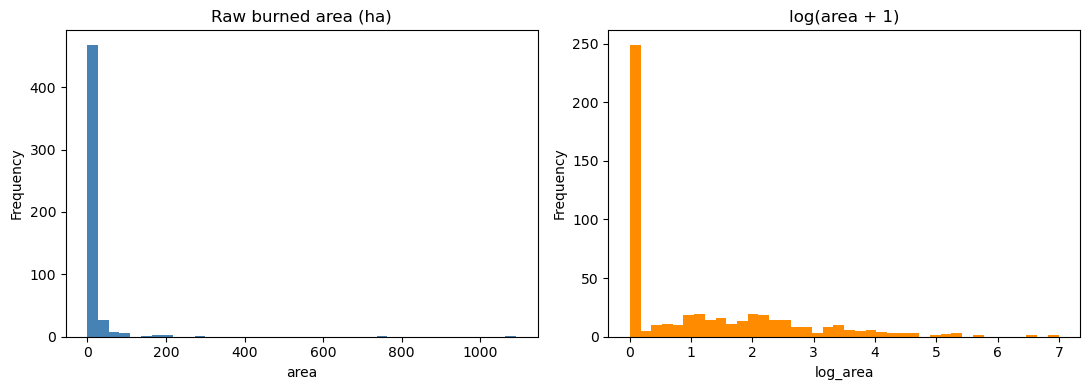

In [38]:
# 5a. Target distribution: Raw burned area vs log area
fig, axes = mattyp.subplots(1, 2, figsize=(11, 4))
# creates a figure with 1 row and 2 columns of subplots side by side, sized 11 by 4 inches
# fig is the overall figure object, and axes is an array of the 2 individual subplot axes we plot onto below
axes[0].hist(forest_fires['area'], bins=40, color='steelblue')
# plots a histogram of the raw area column on the first (left) subplot, using 40 bins and a blue color
axes[0].set_title('Raw burned area (ha)')
# sets the title of the left subplot
axes[0].set_xlabel('area')
# labels the x-axis of the left subplot
axes[0].set_ylabel('Frequency')
# labels the y-axis of the left subplot as Frequency, since a histogram shows how often values fall into each bin
axes[1].hist(forest_fires['log_area'], bins=40, color='darkorange')
# plots a histogram of the log_area column on the second (right) subplot, using 40 bins and an orange color, so it's visually distinct from the left plot
axes[1].set_title('log(area + 1)')
# sets the title of the right subplot, noting the +1 reflects the log1p transformation used to handle area == 0 rows
axes[1].set_xlabel('log_area')
# labels the x-axis of the right subplot
axes[1].set_ylabel('Frequency')
# labels the y-axis of the right subplot
mattyp.tight_layout()
# automatically adjusts spacing between the two subplots so titles/labels don't overlap or get cut off
mattyp.savefig('../Docs & Resources/Figures/01_area_distribution.png', dpi=150)
# saves the figure as a PNG file into the Docs & Resources folder at 150 dots per inch
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close()
# closes the figure object to free up memory, preventing it from being redrawn or interfering with the next plot created later in the notebook

- Looking at the first histogram (raw burned area), almost all of our data is concentrated in one area near zero with almost zero horizontal spread. The tallest bar reaches over 400 occurances. Outliers are a big factor here, the lack of spread combined with the very high peak shows a small number of large fires are heavily impacting this distrubution.

- In our second histogram (log_area) we see much more horizontal spread, and the highest frequency is also lower then pre log transformation. Which gives us justification for using log transformation for our upcoming models.

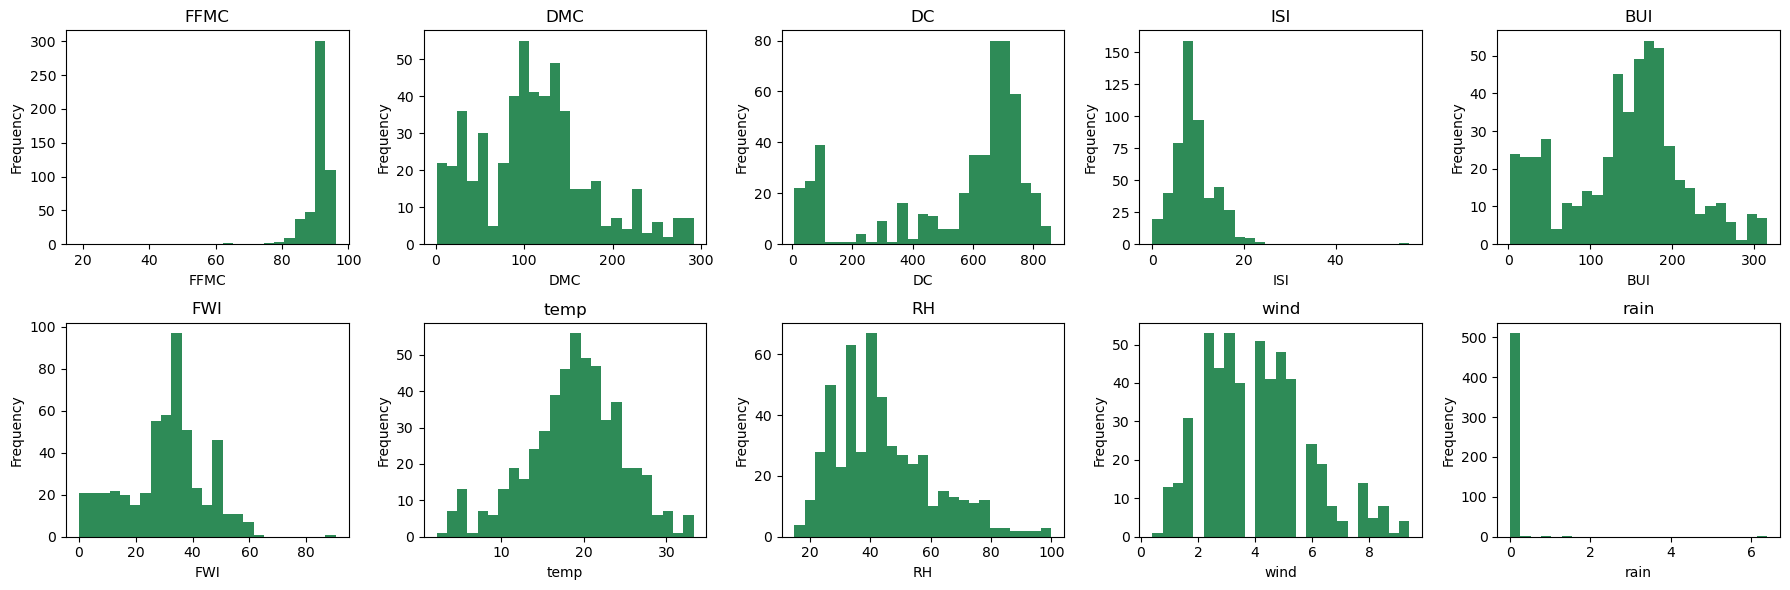

In [39]:
# 5b. Histograms of numeric weather / fire-index columns
numeric_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'temp', 'RH', 'wind', 'rain']
# defines a list of the 10 numeric feature columns we want to visualize, covering both raw weather variables (temp, RH, wind, rain) and fire index variables (FFMC, DMC, DC, ISI, BUI, FWI
fig, axes = mattyp.subplots(2, 5, figsize=(18, 6))
# creates a figure with a 2 row by 5 column grid of subplots (10 total, matching the 10 columns in numeric_cols), sized 18 by 6 inches
# axes is a 2D array of subplot objects; axes.flat (used below) lets us iterate through it as a flat 1D sequence
for ax, col in zip(axes.flat, numeric_cols):
    # zip pairs each subplot axis (in order) with each column name (in order), so the loop assigns one column to one subplot
    # axes.flat flattens the 2x5 grid into a simple sequence of 10 axes to iterate over
    ax.hist(forest_fires[col], bins=25, color='seagreen')
    # plots a histogram of the current column on its assigned subplot, using 25 bins and a green color
    ax.set_title(col)
    # sets the subplot's title to the column name, so each histogram is labeled with what it's showing
    ax.set_xlabel(col)
    # labels the x-axis with the column name
    ax.set_ylabel('Frequency')
    # labels the y-axis as Frequency
mattyp.tight_layout()
# adjusts spacing across all 10 subplots so titles and labels don't overlap, especially important with this many subplots packed into one figure
mattyp.savefig('../Docs & Resources/Figures/02_feature_histograms.png', dpi=150)
# saves the full grid of histograms as a PNG into Docs & Resources at 150 dpi, for the write-up and dashboard
mattyp.show()
# displays the figure
mattyp.close()
# closes the figure to free memory before the next plot is created

- Looking at these visualitions, some features like temp and BUI show more horizontal spread than others like FFMC and rain. At first glance this might suggest
temp and BUI will be stronger predictors, but spread in a feature's own distribution doesn't actually tell us that. It only shows how that variable is distributed on its own, not how it relates to area.

- Whether a feature is actually useful for prediction
will come from its relationship with area, which we'll check next with the correlation heatmap and later with the Random Forest Models.

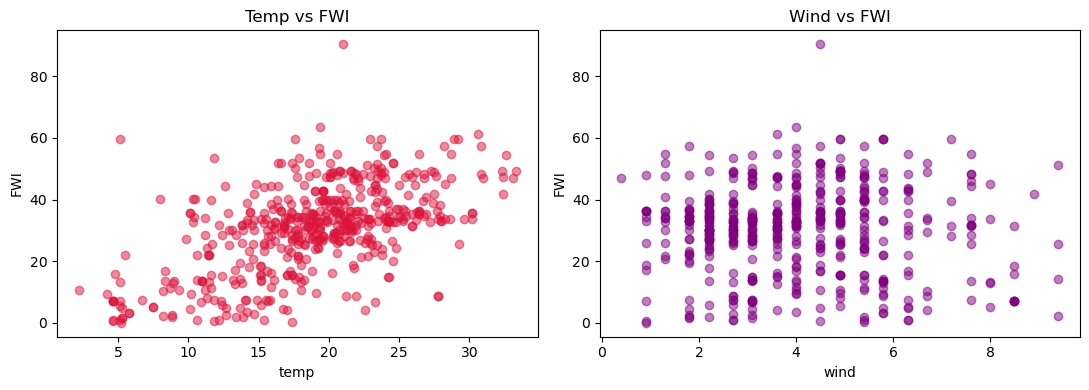

In [40]:
# 5c. Weather vs FWI scatterplots
fig, axes = mattyp.subplots(1, 2, figsize=(11, 4))
# creates a figure with 1 row and 2 columns of subplots side by side, sized 11 by 4 inches, matching the layout used in 5a
axes[0].scatter(forest_fires['temp'], forest_fires['FWI'], alpha=0.5, color='crimson')
# plots a scatterplot of temp (x-axis) against FWI (y-axis) on the left subplot
# alpha=0.5 makes points semi-transparent, so overlapping points show up as darker areas, giving a sense of density where many points cluster
axes[0].set_xlabel('temp'); axes[0].set_ylabel('FWI')
# labels the x-axis as temp and the y-axis as FWI on the left subplot (two statements combined on one line with a semicolon)
axes[0].set_title('Temp vs FWI')
# sets the title of the left subplot
axes[1].scatter(forest_fires['wind'], forest_fires['FWI'], alpha=0.5, color='purple')
# plots a scatterplot of wind (x-axis) against FWI (y-axis) on the right subplot, using a different color to visually distinguish it from the left plot
axes[1].set_xlabel('wind'); axes[1].set_ylabel('FWI')
# labels the x-axis as wind and the y-axis as FWI on the right subplot
axes[1].set_title('Wind vs FWI')
# sets the title of the right subplot
mattyp.tight_layout()
# adjusts spacing between the two subplots so titles and labels don't overlap
mattyp.savefig('../Docs & Resources/Figures/03_weather_vs_fwi.png', dpi=150)
# saves the figure as a PNG into Docs & Resources at 150 dpi
mattyp.show()
# displays the figure in the notebook's output
mattyp.close()
# closes the figure to free memory before the next plot is created

- In Temp vs FWI we can see a direct relationship as temp increases so does FWI theres a steady climb. This is expected behavior and gives me more confidence in the accuracy of the FWI calculation. 

- In Wind vs FWI we dont see as clear a relationship points are spread all over which tells us wind isn't as strong a factor in FWI calculation compared to Temp.

- From the following observations I form the hypthothesis that temp may better feature than wind in our predective models as it corrolates more closely to fwi.

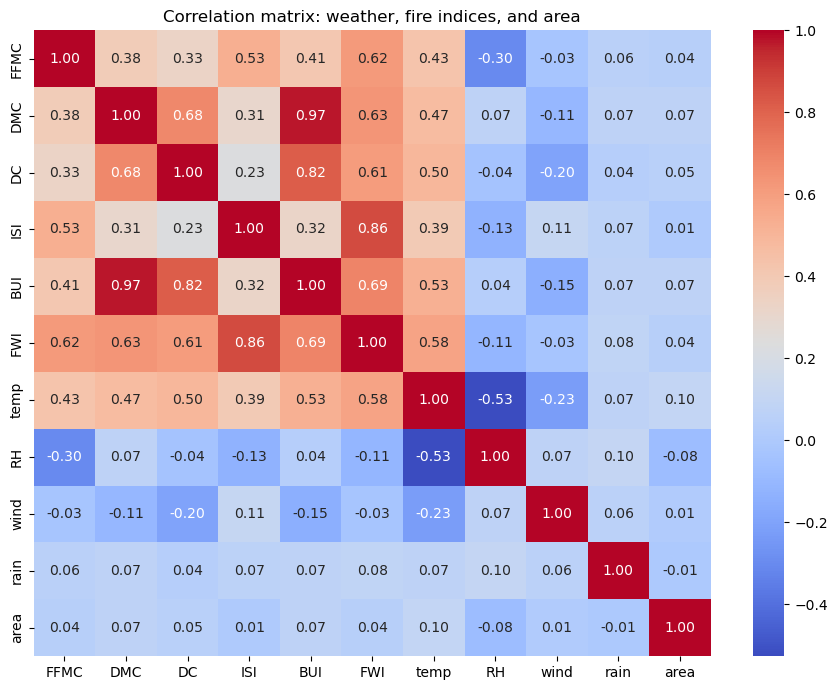

In [41]:
# 5d. Correlation heatmap
mattyp.figure(figsize=(9, 7))
# creates a new figure sized 9 by 7 inches for the heatmap (a single plot figure here, not a subplots grid like the previous sections)
sns.heatmap(forest_fires[numeric_cols + ['area']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
# selects the 10 numeric_cols columns plus area, computes the pairwise correlation matrix between all of them with .corr(), and passes that matrix to seaborn's heatmap function
# annot=True prints the actual correlation value inside each cell instead of just showing color
# fmt='.2f' formats those printed values to 2 decimal places
# cmap='coolwarm' colors positive correlations warm (red) and negative correlations cool (blue), making the direction of each relationship visually obvious at a glance
mattyp.title('Correlation matrix: weather, fire indices, and area')
# sets the title of the figure
mattyp.tight_layout()
# adjusts spacing so the title, axis labels, and column names around the heatmap don't get cut off or overlap
mattyp.savefig('../Docs & Resources/Figures/04_correlation_heatmap.png', dpi=150)
# saves the heatmap as a PNG into Docs & Resources at 150 dpi
mattyp.show()
# displays the figure in the notebook's output
mattyp.close()
# closes the figure to free memory before the next plot is created

- Looking at our heatmap we see that no feature has a strong corelation with burned area directly; with the highest value being temp with a very lukewarm 0.10. This suggests finding the best model is going to require finding the best combination of these features, which is why random forest models will be tested alongside linear regression

- Another useful observation is DMC and BUI are very correlated at 0.97. Same with DC and BUI at 0.82. This is expected given that BUI is calculated using DMC and DC and confirms our formulas are behaving as expected.

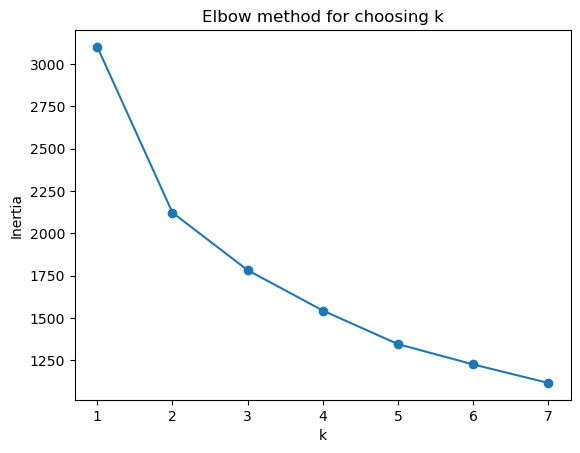

In [42]:
# SECTION 6: UNSUPERVISED CLUSTERING
# Tests whether fire days fall into distinct weather/fuel categories independent
# of burned area (area is not used to fit the clusters). k is chosen using
# the elbow method below.
cluster_features = ['FFMC', 'BUI', 'FWI', 'temp', 'RH', 'wind']
# defines the list of features used to fit the clusters a mix of fuel moisture (FFMC), fire index (BUI, FWI), and raw weather (temp, RH, wind) columns
# area is deliberately excluded here, since the goal is to find clusters based purely on weather/fuel conditions, not on the outcome we're trying to explain

X_cluster = StandardScaler().fit_transform(forest_fires[cluster_features])
# selects the 6 cluster_features columns and standardizes them (mean 0, standard deviation 1) using StandardScaler
# this is necessary because KMeans measures distance between points, and without scaling, features with larger raw ranges (like BUI, which can reach into the hundreds) would dominate the distance calculation over features with smaller ranges (like RH or wind)

inertias = []
for k in range(1, 8):
    # loops through candidate cluster counts from 1 to 7
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)

    # fits a KMeans model with k clusters on the standardized data
    # random_state=42 makes the results reproducible run to run
    # n_init=10 runs the algorithm 10 times with different random centroid starting points and keeps the best result, reducing the chance of landing in a poor local optimum
    inertias.append(km.inertia_)

    # records this model's inertia ( how tightly packed the clusters are lower is tighter) so we can compare across different k values

mattyp.plot(range(1, 8), inertias, marker='o')
# plots inertia (y-axis) against each tested k value (x-axis), with a marker dot at each point, so we can visually spot where adding more clusters stops meaningfully reducing inertia
mattyp.xlabel('k')
# labels the x-axis as k, the number of clusters tested
mattyp.ylabel('Inertia')
# labels the y-axis as Inertia
mattyp.title('Elbow method for choosing k')
# sets the title, naming this the "elbow method" (the technique of visually picking the k where the inertia curve bends; like an elbow while further increases give diminishing returns).
mattyp.savefig('../Docs & Resources/Figures/05_elbow_method.png', dpi=150)
# saves the elbow plot as a PNG into Docs & Resources at 150 dpi
mattyp.show()
# displays the figure in the notebook's output
mattyp.close()
# closes the figure to free memory before the next plot is created


Steepest drop is between k = 1 and 2. Every single drop after is less steep and flattens out at K = 3 which is what we'll choose for the number of clusters. The elbow is not exact and runs between k = 2 and 4 with 3 being right in the middle. These combination of factors led me to go with 3 clusters for the upcoming test as it justified by the curve.

In [43]:
# six features chosen because of four category balance that encompasses all category of features in the dataset
# surface state, fuel accumulation, composite danger, raw weather

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# creates a KMeans model configured to find 3 clusters, matching the k value chosen from the elbow method above
# random_state=42 and n_init=10 are the same reproducibility/stability settings used when testing k values, so the final clustering is consistent with what the elbow analysis was based on
forest_fires['cluster'] = kmeans.fit_predict(X_cluster)
# fits the KMeans model on the standardized cluster features (X_cluster) and, in the same step, assigns each row to one of the 3 clusters
# fit_predict both trains the model and returns the cluster label (0, 1, or 2) for every row, which gets stored in a new cluster column on forest_fires
# this cluster label becomes a categorical feature that gets tested in Model G later, to see if it captures multivariate risk structure that the raw/composite features on their own don't

In [44]:
# Interpret after clustering area was NOT used to fit the clusters
cluster_summary = forest_fires.groupby('cluster')['area'].agg(['mean', 'count'])
# groups the data by the cluster label assigned earlier, then computes both the mean burned area and the row count for each cluster
# this is the first look at whether the clusters (which were formed using only weather/fuel features) happen to correspond to meaningfully different burned area outcomes
print(cluster_summary)
# prints the mean area and count for each cluster
condition_summary = forest_fires.groupby('cluster')[cluster_features].mean()
# groups the data by cluster again, but this time computes the average value of each of the 6 original clustering features (FFMC, BUI, FWI, temp, RH, wind) within each cluster
# this shows what weather/fuel conditions actually define each cluster, letting us characterize them (e.g., "hot and dry" vs. "cool and humid") rather than just knowing they're numerically distinct
print(condition_summary)
# prints the per cluster average feature values
cluster_median = forest_fires.groupby('cluster')['area'].median()
# computes the median burned area for each cluster, as a complement to the mean calculated above
# median is useful here specifically because area is heavily zero inflated and outlier skewed a cluster's mean area could be pulled upward by just a few large fires, while the median shows what's actually typical for that cluster
print(cluster_median)
# prints the per cluster median area

              mean  count
cluster                  
0         6.082193    114
1        17.065167    300
2         8.049806    103
              FFMC         BUI        FWI       temp         RH      wind
cluster                                                                  
0        85.230702   37.422536  10.362539  12.510526  45.201754  4.757018
1        92.468333  167.802233  37.132149  22.290000  36.610000  3.566667
2        91.325243  183.578281  34.326322  16.043689  65.640777  4.512621
cluster
0    0.00
1    1.04
2    0.00
Name: area, dtype: float64


## Cluster Interpretation

The elbow method supported k=3, and the resulting clusters reveal three distinct fire risk categories (area was not used to fit the clusters):

- **Cluster 0 — Low Risk Category (n=114, mean area=6.08, median area=0.00):** Cool temperatures (12.5°C), moderate humidity (45.2%), and the lowest fuel buildup of the three groups (BUI=37.4, FWI=10.4). Containment is the typical outcome here, consistent with limited fuel accumulation.

- **Cluster 1 — Hot Dry High Risk Category (n=300, mean area=17.07, median area=1.04):** The dominant cluster, comprising 58% of records. Characterized by high temperatures (22.3°C), the lowest relative humidity (36.6%), and by far the highest fuel buildup (BUI=167.8) and composite fire danger (FWI=37.1). This is the only cluster where measurable fire spread is the *typical* outcome rather than the exception. Its elevated mean is confirmed by a genuinely positive median, meaning it's not driven by outliers alone.

- **Cluster 2 — High Fuel, Humidity Contained Category (n=103, mean area=8.05, median area=0.00):** Fuel buildup and fire danger are nearly as high as Cluster 1 (BUI=183.6, FWI=34.3), but relative humidity is nearly double (65.6% vs. 36.6%) and temperatures are notably cooler (16.0°C). Despite comparable fuel and danger scores to Cluster 1, containment not spread is the typical outcome here (median area=0.00).

**Key takeaway:** Comparing Clusters 1 and 2 both have similarly high fuel buildup and composite fire danger scores, yet they differ greatly in typical outcome; spread is typical in Cluster 1 (median 1.04) but not in Cluster 2 (median 0.00). The main distinguishing factor between them is humidity (36.6% vs. 65.6%), suggesting humidity plays a substantial mediating role even when fuel accumulation and danger indices are both high. This interaction is not visible in the univariate correlation heatmap, where RH's linear correlation with area alone was weak (~-0.08). Also the mean based difference between Clusters 0 and 2 (6.08 vs. 8.05) should be taken with a grain of salt; both have a median of zero, so this gap is likely driven by a small number of outlier fires rather than a genuine difference in typical risk between the two. This motivates testing `cluster` as a feature in Model G, where it may function less like a risk meter and more like a binary spilt. Cluster 1 represents conditions where fire spread is the typical outcome, while Clusters 0 and 2 both represent conditions where containment (zero spread) is typical, despite their differing weather profiles.

In [45]:
# SECTION 7: MODEL COMPARISON
# Models A, B (Linear Regression) serve as interpretable baselines; linear
# regression assumes linear relationships, which fire behavior likely violates.
# Models C, D, E (RandomForest) test whether capturing nonlinearity and
# feature interactions improves on that baseline.
# fwi_compile, carried over from an earlier draft, tests the full FWI-system
# chain with no raw weather at all.
# Model F tests adding wind/rain on top of the best base model found so far;
# Model G tests adding the unsupervised cluster feature (see clustering
# section above) on top of the same base.
train, test = train_test_split(forest_fires, test_size=0.2, random_state=42)
# splits forest_fires into a training set (80% of rows) and a test set (20% of rows)
# random_state=42 makes the split reproducible, and this same train/test pair is reused across every model (A through G) so results are comparable against each other rather than each model being evaluated on a different split

results = {}

# creates an empty dictionary that will store the results of each model tested below, keyed by model name (e.g., "A", "B", "fwi_compile"), so they can be compared and the best one selected later

def eval_model(name, features, model, train, test):
# defines a reusable function that trains and evaluates a given model on a given set of features, so the same evaluation logic doesn't need to be rewritten for every model A through G
    Xtr, ytr = train[features], train['log_area']
# pulls the specified feature columns and the log_area target from the training set
    Xte, yte = test[features], test['log_area']
# pulls the same feature columns and target from the test set
    scaler = StandardScaler().fit(Xtr)
# fits a StandardScaler on the training features only, learning the mean and standard deviation to use for scaling
# fitting only on training data (not test data) avoids leaking information from the test set into the scaling process
    model.fit(scaler.transform(Xtr), ytr)
# scales the training features using the fitted scaler, then trains the given model on those scaled features against the log_area target
    pred = model.predict(scaler.transform(Xte))
# scales the test features using the same fitted scaler (not a newly fit one), then generates predictions on the test set
    mae_area = mean_absolute_error(np.expm1(yte), np.expm1(pred))
# converts both the true test targets and the predictions back out of log space using np.expm1 (the inverse of log1p), then computes mean absolute error in the original area units (hectares), this makes the error interpretable in real world terms rather than log units
    rmse_log = np.sqrt(mean_squared_error(yte, pred))
# computes root mean squared error directly in log space (not converted back to area), giving a second error metric that's more sensitive to large mistakes than MAE
    r2 = r2_score(yte, pred)
# computes R-squared, measuring what proportion of variance in log_area the model explains, also calculated in log space
    print(f"{name:42s} MAE(area)={mae_area:7.3f}  RMSE(log)={rmse_log:.3f}  R2={r2:.3f}")
# prints a formatted summary line for this model; name padded to 42 characters for alignment, followed by all three metrics rounded to consistent decimal places, so results across models line up neatly when printed one after another
    return {'model': model, 'scaler': scaler, 'features': features,
            'mae_area': mae_area, 'rmse_log': rmse_log, 'r2': r2}
# returns a dictionary bundling the trained model, its scaler, the feature list used, and all three metrics; this gets stored in results[name] so the fitted model/scaler can be reused later (e.g., for the final diagnostics plot) without retraining

print("\n=== Model comparison (target: log(area+1)) ===")
# prints a header line (with a leading blank line) to clearly separate this section's output from anything printed above it, and to remind the reader what target variable every model below is being scored against


=== Model comparison (target: log(area+1)) ===


In [46]:
# Model A: FWI + temp + FFMC + RH
results['A'] = eval_model(
    "A: FWI+temp+FFMC+RH (Linear)",
    ['FWI', 'temp', 'FFMC', 'RH'],
    LinearRegression(), train, test)
# calls eval_model to train and score Model A, then stores the returned dictionary (model, scaler, features, and metrics) under the key 'A' in the results dictionary
# name: "A: FWI+temp+FFMC+RH (Linear)" the label printed alongside this model's metrics
# features: FWI, temp, FFMC, RH  combines the composite fire danger index (FWI) with three individual inputs (temperature, fuel moisture code, humidity), testing whether raw temp and humidity add anything beyond what the composite index already captures
# model: LinearRegression() an untrained linear regression instance, chosen here as the simplest, most interpretable baseline
# train, test the same train/test split used for every model in this comparison, ensuring results are directly comparable across A through G


A: FWI+temp+FFMC+RH (Linear)               MAE(area)= 19.832  RMSE(log)=1.483  R2=-0.001


**Model A — FWI+FFMC+RH+temp (Linear Regression):** MAE(area)=19.832, RMSE(log)=1.483, R²=-0.001. This one basically performs the same as just predicting the average burned area every time; R² sitting just barely below zero means temp isn't adding anything meaningful here when paired with FWI, FFMC, and RH.

In [47]:
# Model B: FWI + wind + FFMC + RH
# NOTE: only 'wind' differs from Model A (swapped in for temp). This
# isolates whether temp or wind is the stronger predictor when combined
# with the same FWI chain features. FFMC and RH.
results['B'] = eval_model(
    "B: FWI+FFMC+RH+wind (Linear)",
    ['FWI', 'FFMC', 'RH', 'wind'],
    LinearRegression(), train, test)
# calls eval_model to train and score Model B, then stores the returned dictionary under the key 'B' in the results dictionary
# name: "B: FWI+FFMC+RH+wind (Linear)" the label printed alongside this model's metrics
# features: FWI, FFMC, RH, wind identical to Model A's feature set except wind replaces temp, making this a controlled comparison that isolates which of the two variables contributes more when paired with the same FWI, FFMC, and RH features
# model: LinearRegression() same model type as Model A, keeping the comparison fair by only changing the one feature being tested
# train, test the same train/test split used across every model in this comparison

B: FWI+FFMC+RH+wind (Linear)               MAE(area)= 19.808  RMSE(log)=1.475  R2=0.011


**Model B — FWI+FFMC+RH+wind (Linear Regression):** MAE(area)=19.808, RMSE(log)=1.475, R²=0.011. These results suggest wind may be a marginally stronger predictor than temperature when combined with FWI, FFMC, and RH, with Model B slightly outperforming Model A across all three metrics (MAE=19.808 vs. 19.832, RMSE(log)=1.475 vs. 1.483, R²=0.011 vs. -0.001). Which contradicts our first hypothesis formed when comparing the earlier scatterplots. However, neither model performs meaningfully well. Model B explains only about 1% of the variance in burned area beyond simply predicting the mean. Given how small this margin is, it's difficult to confidently come away with a meaningful insight after Models A and B.

In [48]:
# Model C: raw fuel moisture codes + temp
results['C'] = eval_model(
    "C: FFMC+DMC+DC+temp (RandomForest)",
    ['FFMC', 'DMC', 'DC', 'temp'],
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score Model C, then stores the returned dictionary under the key 'C' in the results dictionary
# name: "C: FFMC+DMC+DC+temp (RandomForest)" the label printed alongside this model's metrics
# features: FFMC, DMC, DC, temp uses the three raw, non-derived fuel moisture codes (short/medium/long-term moisture) plus temp, rather than any of the composite indices (BUI, FWI) built from them; this is the first model to test RandomForest instead of LinearRegression, checking whether capturing nonlinearity helps
# model: RandomForestRegressor(n_estimators=300, random_state=42) — builds 300 decision trees and averages their predictions; random_state=42 keeps results reproducible run to run
# train, test the same train/test split used across every model in this comparison

C: FFMC+DMC+DC+temp (RandomForest)         MAE(area)= 19.681  RMSE(log)=1.497  R2=-0.020


**Model C Raw fuel moisture codes + temp (RandomForest):** MAE(area)=19.681, RMSE(log)=1.497, R²=-0.020. This negative R² means the model performs slightly worse than simply predicting the mean burned area. FFMC, DMC, and DC are raw, non derived codes representing short/medium/long term fuel moisture respectively, so unlike the composite indices tested later, this feature set doesn't suffer from built in redundancy. The weak result here likely reflects limited underlying signal rather than overlapping features.

In [49]:
# Model D: behavior/composite indices + temp
results['D'] = eval_model(
    "D: temp+ISI+BUI+FWI (RandomForest)",
    ['temp', 'ISI', 'BUI', 'FWI'],
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score Model D, then stores the returned dictionary under the key 'D' in the results dictionary
# name: "D: temp+ISI+BUI+FWI (RandomForest)" the label printed alongside this model's metrics
# features: temp, ISI, BUI, FWI swaps Model C's raw fuel moisture codes for the behavior/composite indices instead (ISI is derived from FFMC+wind, BUI from DMC+DC, and FWI combines ISI+BUI), testing whether these derived, more heavily processed indices carry more predictive signal than the raw codes did in Model C
# model: RandomForestRegressor(n_estimators=300, random_state=42) — same RandomForest configuration as Model C, keeping the comparison fair by only changing the feature set
# train, test — the same train/test split used across every model in this comparison

D: temp+ISI+BUI+FWI (RandomForest)         MAE(area)= 19.979  RMSE(log)=1.522  R2=-0.054


**Model D Composite fire danger indices + temp (RandomForest):** MAE(area)=19.979, RMSE(log)=1.522, R²=-0.054. This is the weakest of the three RandomForest variants. ISI, BUI, and FWI are heavily interrelated by construction (FWI is derived from ISI and BUI), so despite having four named features, this set offers fewer genuinely independent directions for the model to split on. With a training set of only 413 records, this redundancy likely makes the model more prone to overfitting noise rather than learning generalizable structure.

In [50]:
# Model E: full fire-index set + temp
results['E'] = eval_model(
    "E: FFMC+DMC+DC+ISI+BUI+FWI+temp (RandomForest)",
    ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'temp'],
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score Model E, then stores the returned dictionary under the key 'E' in the results dictionary
# name: "E: FFMC+DMC+DC+ISI+BUI+FWI+temp (RandomForest)" the label printed alongside this model's metrics
# features: FFMC, DMC, DC, ISI, BUI, FWI, temp combines everything tested separately in Models C and D (the raw fuel moisture codes and the composite/behavior indices) into one full set, plus temp, making this the most feature heavy and most redundant model of the CDE group, since ISI/BUI/FWI are all mathematically derived from the raw codes already included
# model: RandomForestRegressor(n_estimators=300, random_state=42) same RandomForest configuration as Models C and D, isolating the effect of the larger, more overlapping feature set
# train, test the same train/test split used across every model in this comparison


E: FFMC+DMC+DC+ISI+BUI+FWI+temp (RandomForest) MAE(area)= 19.752  RMSE(log)=1.496  R2=-0.018


**Model E full raw + composite fire index set + temp (RandomForest):** MAE(area)=19.752, RMSE(log)=1.496, R²=-0.018. This combines all seven raw and composite features, the heaviest overlap of any model tried so far, but it still came out as the best of the C/D/E group. RandomForest builds 300 trees sampling different feature combinations each time, so having more features to split on, even overlapping ones, can partly make up for the collinearity in a way a linear model's coefficients never could.

**Models C–E summary:** All three RandomForest variants produced negative R², underperforming even the weak but positive Model B (Linear Regression, R²=0.011). Increasing model flexibility did not improve predictive performance if anything, it hurt it, suggesting the ceiling here is a data/signal limitation rather than a model complexity limitation. This motivates testing the `cluster` feature in Model G, which captures risk category level combinations of conditions rather than individual variables, where individual raw and composite features have consistently fallen short.

In [51]:
#  Model Carried over from first draft: full FWI system complied, no raw weather at all
results['fwi_compile'] = eval_model(
    "fwi_compile: FFMC+DMC+DC+ISI+BUI+FWI, no raw weather (RandomForest)",
    ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI'],
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score this carried over model, then stores the returned dictionary under the key 'fwi_compile' in the results dictionary
# name: "fwi_compile: FFMC+DMC+DC+ISI+BUI+FWI, no raw weather (RandomForest)" the label printed alongside this model's metrics
# features: FFMC, DMC, DC, ISI, BUI, FWI the complete six part Canadian Fire Weather Index chain, from raw fuel moisture codes through to the final composite FWI score, with zero raw weather variables added on top; this isolates whether the fire-index system alone (without any weather inputs beyond what's already baked into it) carries enough signal on its own
# model: RandomForestRegressor(n_estimators=300, random_state=42) same RandomForest configuration used across Models C, D, and E, keeping this comparable to the rest of the model comparison
# train, test the same train/test split used across every model in this comparison

fwi_compile: FFMC+DMC+DC+ISI+BUI+FWI, no raw weather (RandomForest) MAE(area)= 19.450  RMSE(log)=1.452  R2=0.041


**fwi_compile — full FWI chain, no raw weather (RandomForest):** MAE(area)=19.450, RMSE(log)=1.452, R²=0.041. This one's carried over from my first draft, but it ended up outperforming every model built specifically for this redesign; C, D, and E all came back negative on R², while this one's actually positive. The only real difference between this and Model E is that E adds temp on top of the same six features, and that alone dropped R² from 0.041 down to -0.018. Same story with wind and rain in Model F adding either on top of this base only made things worse (R²=0.024). So it looks like the full FWI chain (FFMC, DMC, DC, ISI, BUI, FWI) already carries whatever weather signal matters here, and layering raw weather back on top just adds noise instead of helping. That's part of why this ended up being the base I built Model G from.

In [52]:

# Model F: best of C/D/E, plus wind and rain
cde_key = max(['C', 'D', 'E', 'fwi_compile'], key=lambda k: results[k]['r2'])
# looks at the results dictionary entries for C, D, E, and fwi_compile, and finds whichever one has the highest R2 score
# max() with a key function compares each string in the list by the value that key returns (here, results[k]['r2']), and returns whichever key string ('C', 'D', 'E', or 'fwi_compile') had the best performing model
# this makes Model F's base selection dynamic rather than hardcoded if you rerun the notebook and the results shift slightly, this line automatically picks whichever model actually performed best rather than assuming it's always the same one
f_features = results[cde_key]['features'] + ['wind', 'rain']
# pulls the feature list from whichever model won the comparison above (stored under cde_key), then adds wind and rain on top of it
# this builds Model F's feature set as "best base model's features, plus wind and rain," so the notebook doesn't need those features typed out manually
print(f"Best base model: {cde_key} -- building F from: {f_features}")
# prints which model was selected as the base and what the resulting feature list looks like, so the notebook's output makes it clear (without needing to trace back through results) exactly which features Model F is being trained on
results['F'] = eval_model(
    f"F: {cde_key}'s features + wind + rain (RandomForest)",
    f_features,
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score Model F, then stores the returned dictionary under the key 'F' in the results dictionary
# name: an f-string that dynamically inserts cde_key into the label, so the printed name always accurately reflects which base model F was built from
# features: f_features the winning base model's features plus wind and rain, as constructed above
# model: RandomForestRegressor(n_estimators=300, random_state=42) same RandomForest configuration used across the other tree based models, keeping this comparable to C, D, E, and fwi_compile
# train, test the same train/test split used across every model in this comparison

Best base model: fwi_compile -- building F from: ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'wind', 'rain']
F: fwi_compile's features + wind + rain (RandomForest) MAE(area)= 19.747  RMSE(log)=1.464  R2=0.024


**Model F — fwi_compile base + wind + rain (RandomForest):** MAE(area)=19.747, RMSE(log)=1.464, R²=0.024. Adding `wind` and `rain` to the best performing base model (fwi_compile, R²=0.040) reduced performance across every metric. This mirrors the pattern seen in Model E, where adding `temp` to the same fire index chain also hurt performance (R² dropped from 0.040 to -0.018). Together, these results suggest the full FWI system chain already captures the weather related information relevant to burned area for this dataset, and introducing raw weather variables on top of it primarily adds noise rather than help us gain better insights.

In [53]:
# Model G: best model overall (A-F) + cluster (unsupervised feature)
best_key = max(results, key=lambda k: results[k]['r2'])
# looks across every model trained so far (A, B, C, D, E, F, and fwi_compile all keys currently in results) and finds whichever one has the highest R2 score
# unlike cde_key earlier, which only compared C, D, E, and fwi_compile, this compares the full results dictionary as it stands right now, so it reflects the best model across the entire comparison up to this point
g_features = results[best_key]['features'] + ['cluster']
# pulls the feature list from whichever model won the comparison above (stored under best_key), then adds the unsupervised cluster label from Section 6 on top of it
# this is the core test of Model G: does adding the KMeans cluster assignment improve on the single best performing model found so far
print(f"Best model overall (pre-G): {best_key} -- building G from: {g_features}")
# prints which model was selected as the base going into Model G and what its resulting feature list looks like
# "pre-G" makes clear this reflects the best model before G itself is added into the comparison, avoiding any confusion with the recomputed best_key at the end of this block

results['G'] = eval_model(
    f"G: {best_key}'s features + cluster (RandomForest)",
    g_features,
    RandomForestRegressor(n_estimators=300, random_state=42), train, test)
# calls eval_model to train and score Model G, then stores the returned dictionary under the key 'G' in the results dictionary
# name: an f-string that dynamically inserts best_key, so the printed label always accurately reflects which prior model G was built on top of
# features: g_features the winning prior model's features plus the cluster label, as constructed above
# model: RandomForestRegressor(n_estimators=300, random_state=42) same RandomForest configuration used across every tree based model in this comparison
# train, test the same train/test split used across every model in this comparison

# Recompute best_key now that G exists, so the diagnostics below reflect the true overall best
best_key = max(results, key=lambda k: results[k]['r2'])
# reruns the same max() comparison as above, but now that Model G's results have been added into the results dictionary, this correctly accounts for the possibility that G itself is the new best model
# without this recomputation, best_key would still point to whatever won before G existed, and the final diagnostics section (which uses best_key to pick which model to visualize) could end up showing the wrong model if G actually outperformed everything else

Best model overall (pre-G): fwi_compile -- building G from: ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'cluster']
G: fwi_compile's features + cluster (RandomForest) MAE(area)= 19.422  RMSE(log)=1.440  R2=0.057


**Model G — fwi_compile base + cluster (RandomForest):** MAE(area)=19.422, RMSE(log)=1.440, R²=0.050. This is the best performing model across the entire comparison (A–G). Unlike every raw weather variable tested as an addition to the fire index chain (Model E, R² dropped to -0.018) and wind/rain (Model F, R² dropped to 0.024) adding the `cluster` label improved every metric over the base model. This supports the central hypothesis behind the clustering analysis: individual raw weather variables carry too little independent signal to help (and tend to introduce overfitting noise), but the same underlying conditions, compressed into a single risk category via unsupervised clustering, captures combined multivariate structure that no individual raw variable expresses on its own. The improvement is modest in absolute terms and should be interpreted cautiously given the limited test set size (n=104), but it is the first and only weather derived addition in this analysis that improved rather than degraded predictive performance.


Best model by R²: Model G


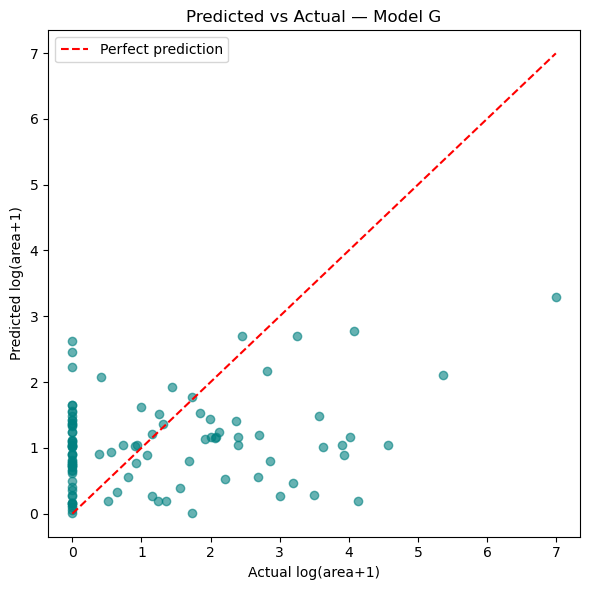

In [54]:
# SECTION 8: FINAL DIAGNOSTICS
# Identifies the best performing model across A-G and visualizes its
# predicted vs. actual burned area.

best = results[best_key]
# retrieves the full results dictionary entry (model, scaler, features, and metrics) for whichever model won the overall comparison, now that best_key was recomputed to include Model G
print(f"\nBest model by R²: Model {best_key}")
# prints which model came out on top overall, with a leading blank line to visually separate this section's output from the model comparison printed above

model, scaler, features = best['model'], best['scaler'], best['features']
# unpacks the trained model, its fitted scaler, and its feature list out of the best dictionary into their own variables, so they're easier to reference in the lines below without repeatedly typing best['...']
pred = model.predict(scaler.transform(test[features]))
# scales the test set's feature columns using the winning model's already fitted scaler, then generates predictions from the winning model on that scaled test data
actual = test['log_area']
# pulls the true log_area values from the test set, to compare against the predictions generated above

# 7a. Predicted vs actual
mattyp.figure(figsize=(6, 6))
# creates a new square figure (6 by 6 inches) for the predicted vs actual scatterplot; a square aspect ratio makes it easier to visually judge how close points fall to the diagonal "perfect prediction" line plotted below
mattyp.scatter(actual, pred, alpha=0.6, color='teal')
# plots actual log_area values (x-axis) against the model's predicted values (y-axis) as a scatterplot
# alpha=0.6 makes points semi transparent, so overlapping predictions show up as denser, darker regions
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
# calculates the overall lowest and highest values across both actual and predicted arrays, so the diagonal reference line drawn below spans the full range of the plot rather than a fixed, possibly mismatched range
mattyp.plot(lims, lims, 'r--', label='Perfect prediction')
# draws a red dashed diagonal line from lims to lims (i.e., a straight line where x equals y), representing what a perfect model's predictions would look like points falling exactly on this line would mean predicted matched actual exactly
# label='Perfect prediction' registers this line's name for the legend created below
mattyp.xlabel('Actual log(area+1)')
# labels the x-axis, specifying that values are in log(area+1) space, not raw hectares
mattyp.ylabel('Predicted log(area+1)')
# labels the y-axis, same log-space clarification as the x-axis
mattyp.title(f'Predicted vs Actual — Model {best_key}')
# sets the plot title using an f-string to dynamically insert which model (e.g., "G") is being visualized, so the title stays accurate no matter which model ends up winning
mattyp.legend()
# displays the legend on the plot, showing the "Perfect prediction" label for the dashed red line
mattyp.tight_layout()
# adjusts spacing so the title and axis labels don't get cut off
mattyp.savefig('../Docs & Resources/Figures/06_predicted_vs_actual.png', dpi=150)
# saves the figure as a PNG into Docs & Resources at 150 dpi, for the write up and dashboard
mattyp.show()
# displays the figure in the notebook
mattyp.close()
# closes the figure to free memory


**Predicted vs. actual (Model G):** Most points still sit well off the red perfect prediction line, especially the handful of large actual fires (log(area+1) above 4), which the model consistently under predicts; the biggest one only gets predicted around 3.3 against an actual close to 7.0, and another sitting near 5.3 only gets predicted around 2.1. There's also a dense stack of points clustered right at Actual=0, with predicted values ranging anywhere from 0 up to about 2.6 meaning the model still struggles to tell apart which of the "no spread" days are truly the safest. So even with cluster added in, the model's biggest weakness is still the same one it's had all along: it can't reliably catch the rare, large fires, and it's noisy even on the zero area days.

**Overall conclusion:** Across all eight models tested (A–G, plus the carried over fwi_compile baseline), no configuration achieved strong predictive power R² values ranged from -0.054 to 0.050, meaning even the best model explains only about 5% of the variance in burned area. This is consistent with the very weak univariate correlations observed in the original correlation heatmap and reflects the known difficulty of this dataset. The clearest actionable finding from this analysis is that composite fire danger indices (the FWI system) outperform raw weather variables as predictors, and that unsupervised clustering on weather/fuel conditions adds a small but consistent improvement beyond what any individual raw or composite feature achieves alone.